In [34]:
# %load_ext autoreload
%reload_ext autoreload
%autoreload 2

import pandas as pd
from eval_helpers import read_dataset, compute_group_variance, plot_computed_results, display_pivoted_results

df = read_dataset("eval_results")
df["total_tokens"] = df["input_token_count"] + df["output_token_count"]
# jupyter nbconvert --to html --no-input eval_report.ipynb

Analysis path
- reasoning token count (output as a proxy for non-gpt-oss evals) by correct; eg at some point seems like overthinking leads to the wrong path, so in prod may want to cap reasoning tokens; proxy for both latency and costs
- consistent passes, failures (finickyness); should NOT depend on harness? have some filters applied in research.ipynb go from there, but make sure to report on test name since irrelevance skew things up weirdly if grouped into a single bucket (and make a point to report that, eg hey look how this appears buuuuuut)

Baseline experiment - set up bfcl fc 0/1

In [35]:
# # 1. Fill missing error types with "no_error" to represent successful runs
# df_clean = df.copy()
# df_clean["error_type"] = df_clean["error_type"].fillna("no_error")

# # 2. Calculate the percentage of each error_type per seed, automatically filling missing ones with 0.0
# # This ensures that seeds with 0% errors are counted, giving us a true standard deviation
# error_rates = (
#     df_clean.groupby(["backend", "wire_api", "test_name", "seed", "fc_model"])["error_type"]
#     .value_counts(normalize=True)      # Computes the rate (e.g. 0.20)
#     .unstack(fill_value=0.0)           # Turns error types into columns and fills missing with 0.0
#     .stack()                           # Flattens it back into rows
#     .reset_index(name="error_rate")    # Converts it back to a clean DataFrame
# )

# # 3. Filter out the "no_error" (successful) rows so we only analyze actual errors
# error_rates = error_rates[error_rates["error_type"] != "no_error"]

# # 1. Define your parameters
# index_cols = ["backend", "error_type", "fc_model"]
# col_cols = ["test_name"]
# variance_col = "seed"
# metric_col = "error_rate"     # <-- Use our new calculated rate column
# query_filter = "reasoning_effort == 'medium' and is_error == 1"

# group_cols = index_cols + col_cols

# # 2. Compute variance using the preprocessed error_rates DataFrame
# out = compute_group_variance(error_rates, group_cols, variance_col, metric_col, query_filter=None)
# # print(out)
# # 3. Display Leaderboard
# display_pivoted_results(
#     df=out,
#     index_cols=index_cols,
#     col_cols=col_cols,
#     metric_col=metric_col,
#     precision=4,
#     title="Model Error Taxonomy Rates (by Test Type)",
#     caption="* Values represent the mean error occurrence rate ± standard deviation across 8 seeds.",
#     rag=True
# )

In [36]:
# baseline experiment - accuracy
index_cols = ["backend", "fc_model", "reasoning_effort", "failure_mode"]
col_cols = ["test_name"]
variance_col = "seed"
metric_col = "correct"
query_filter = "backend.str.startswith('burrito', na=False) and wire_api == 'responses'"

group_cols = index_cols + col_cols
out = compute_group_variance(df, group_cols, variance_col, metric_col, query_filter)

caption = "Table 1: accuracy across backend and wire api x fc_model. Values represent mean ± standard deviation across 8 seeds."

display_pivoted_results(
    df=out,
    index_cols=index_cols,
    col_cols=col_cols,
    metric_col=metric_col,
    precision=4,
    caption=caption
)
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# print(df.head())

In [53]:
# baseline experiment - latency

index_cols = ["backend", "wire_api", "reasoning_effort", "fc_model"]
col_cols = ["test_name"]
variance_col = "seed"
metric_col = "correct"
query_filter = "test_type == 'GPT-OSS'"


group_cols = index_cols + col_cols
out = compute_group_variance(df, group_cols, variance_col, metric_col, query_filter)

caption = "Table 2: latency across backend and wire api x fc_model. Values represent mean ± standard deviation across 8 seeds."

display_pivoted_results(
    df=out,
    index_cols=index_cols,
    col_cols=col_cols,
    metric_col=metric_col,
    precision=4,
    caption=caption
)

In [38]:
# baseline experiment - latency
index_cols = ["backend", "fc_model", "wire_api", "reasoning_effort"]
col_cols = ["test_name"]
variance_col = "seed"
metric_col = "is_error"
query_filter = "backend.str.startswith('vllm', na=False)" #None #"reasoning_effort == 'medium'"

group_cols = index_cols + col_cols
out = compute_group_variance(df, group_cols, variance_col, metric_col, query_filter)

caption = "Table 2: latency across backend and wire api x fc_model. Values represent mean ± standard deviation across 8 seeds."

display_pivoted_results(
    df=out,
    index_cols=index_cols,
    col_cols=col_cols,
    metric_col=metric_col,
    precision=4,
    caption=caption
)

In [39]:
# baseline experiment - latency
index_cols = ["backend", "wire_api", "fc_model"]
col_cols = ["test_name"]
variance_col = "seed"
metric_col = "latency"
query_filter = "reasoning_effort == 'medium'"

group_cols = index_cols + col_cols
out = compute_group_variance(df, group_cols, variance_col, metric_col, query_filter)

caption = "Table 2: latency across backend and wire api x fc_model. Values represent mean ± standard deviation across 8 seeds."

display_pivoted_results(
    df=out,
    index_cols=index_cols,
    col_cols=col_cols,
    metric_col=metric_col,
    precision=4,
    caption=caption
)

In [40]:
index_cols = ["backend", "wire_api", "fc_model"]    # Nested Row Headers (The configurations)
col_cols = ["test_name"]    # Column Headers (The benchmark tasks)

variance_col = "seed"
metric_col = "correct"
query_filter = "reasoning_effort == 'medium'"
# query_filter = "backend.str.startswith('burrito', na=False)"

group_cols = index_cols + col_cols

out = compute_group_variance(df, group_cols, variance_col, metric_col, query_filter)
display_pivoted_results(out, index_cols, col_cols, metric_col)

In [41]:
index_cols = ["backend", "wire_api", "fc_model"]    # Nested Row Headers (The configurations)
col_cols = ["test_name"]    # Column Headers (The benchmark tasks)

variance_col = "seed"
metric_col = "is_error"
query_filter = "reasoning_effort == 'medium'"
# query_filter = "backend.str.startswith('burrito', na=False)"

group_cols = index_cols + col_cols

out = compute_group_variance(df, group_cols, variance_col, metric_col, query_filter)
display_pivoted_results(out, index_cols, col_cols, metric_col)

In [42]:
index_cols = ["backend", "wire_api", "fc_model"]    # Nested Row Headers (The configurations)
col_cols = ["test_name"]    # Column Headers (The benchmark tasks)

variance_col = "seed"
metric_col = "correct"
query_filter = "reasoning_effort == 'medium'"
# query_filter = "backend.str.startswith('burrito', na=False)"

group_cols = index_cols + col_cols

out = compute_group_variance(df, group_cols, variance_col, metric_col, query_filter)
display_pivoted_results(out, index_cols, col_cols, metric_col)

In [43]:
index_cols = ["backend", "fc_model", "reasoning_effort", "python_enabled"]    # Nested Row Headers (The configurations)
col_cols = ["test_name"]    # Column Headers (The benchmark tasks)

variance_col = "seed"
metric_col = "latency"
# query_filter = "reasoning_effort == 'medium'"
query_filter = "backend.str.startswith('burrito', na=False) and test_type != 'gpt_oss'"

group_cols = index_cols + col_cols

out = compute_group_variance(df, group_cols, variance_col, metric_col, query_filter)
display_pivoted_results(out, index_cols, col_cols, metric_col)
display(df.head())

,run_name,backend,wire_api,model_name,fc_model,test_id,test_name,test_type,browser_enabled,python_enabled,...,mt_output_token_count_success,mt_latency_success,mt_num_turns_total,mt_num_turns_success,mt_num_turns_success_pct,is_error,error_type,error_message,failure_mode,total_tokens
0,burrito@llamacpp_chat_medium_t-1_b-1_f-0_s-680867,burrito@llamacpp,chat,gpt-oss-20b,0,multi_turn_base_0,multi_turn_base,multi_turn,0,0,...,0,0.000000,4,0,0.0,0,multi_turn:empty_turn_model_response,Model response list is empty for turn 0,model,87590
1,burrito@llamacpp_chat_medium_t-1_b-1_f-0_s-680867,burrito@llamacpp,chat,gpt-oss-20b,0,multi_turn_base_1,multi_turn_base,multi_turn,0,0,...,1543,17.716507,4,4,100.0,0,NaN,NaN,success,39175
2,burrito@llamacpp_chat_medium_t-1_b-1_f-0_s-680867,burrito@llamacpp,chat,gpt-oss-20b,0,multi_turn_base_10,multi_turn_base,multi_turn,0,0,...,0,0.000000,5,0,0.0,0,multi_turn:empty_turn_model_response,Model response list is empty for turn 0,model,36485
3,burrito@llamacpp_chat_medium_t-1_b-1_f-0_s-680867,burrito@llamacpp,chat,gpt-oss-20b,0,multi_turn_base_100,multi_turn_base,multi_turn,0,0,...,0,0.000000,2,0,0.0,0,multi_turn:empty_turn_model_response,Model response list is empty for turn 0,model,9627
4,burrito@llamacpp_chat_medium_t-1_b-1_f-0_s-680867,burrito@llamacpp,chat,gpt-oss-20b,0,multi_turn_base_101,multi_turn_base,multi_turn,0,0,...,0,0.000000,3,0,0.0,0,multi_turn:empty_turn_model_response,Model response list is empty for turn 0,model,19969


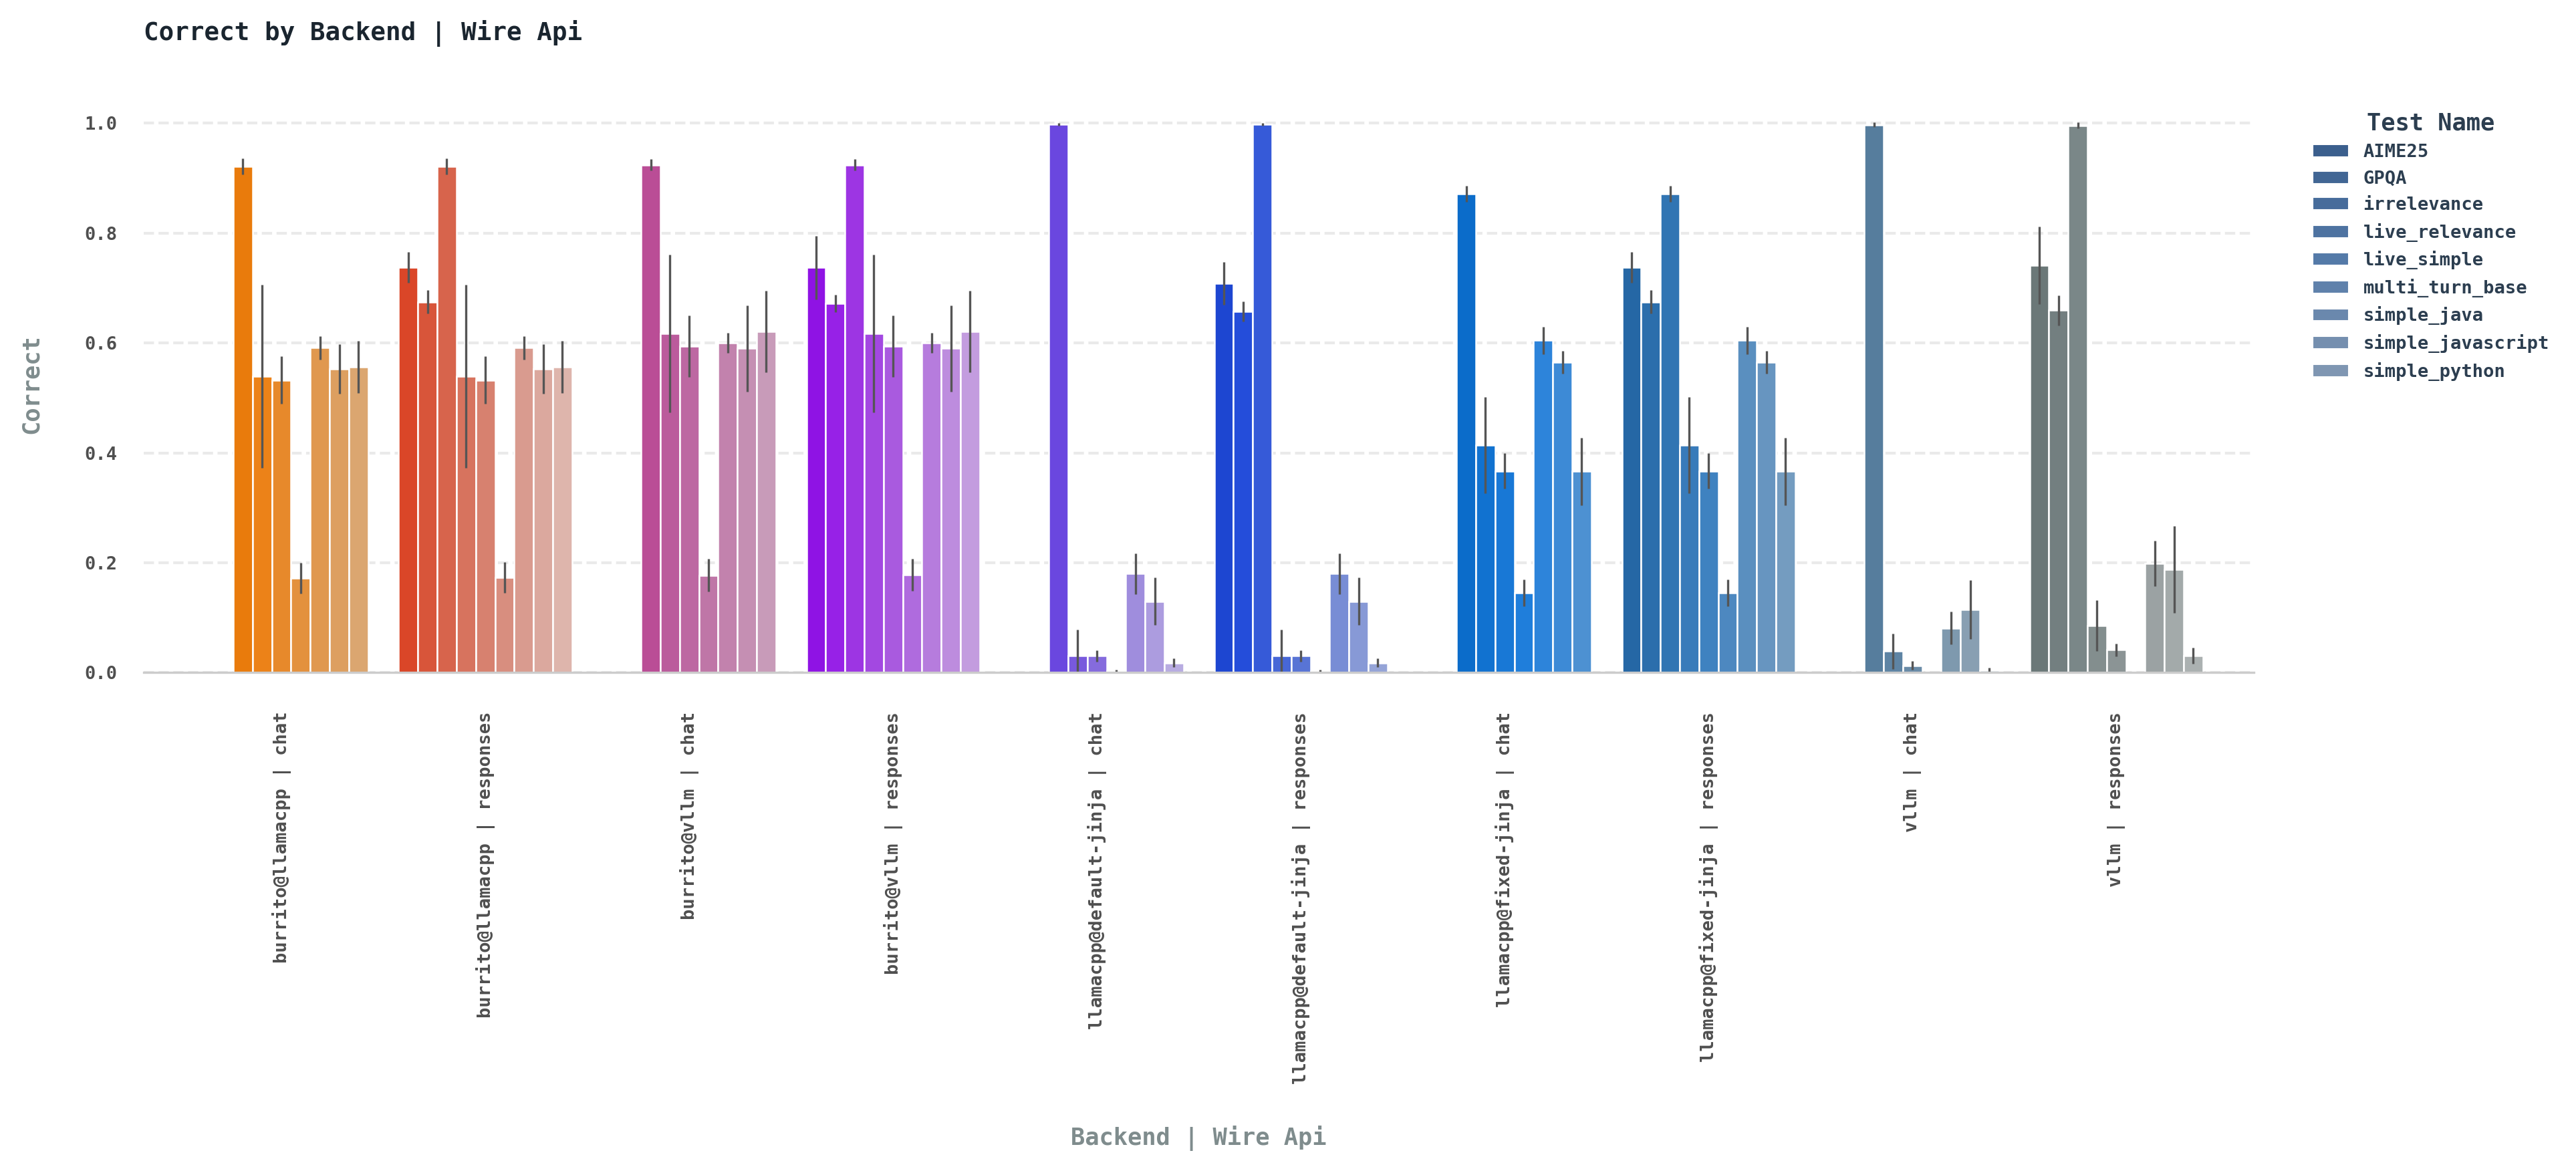

In [44]:
index_cols = ["backend", "wire_api"]    # Nested Row Headers (The configurations)
col_cols = ["test_name"]    # Column Headers (The benchmark tasks)

variance_col = "seed"
metric_col = "correct"
query_filter = "fc_model == 0 and reasoning_effort == 'medium'"
# query_filter = "backend.str.startswith('burrito', na=False)"

group_cols = index_cols + col_cols

out = compute_group_variance(df, group_cols, variance_col, metric_col, query_filter)
plot_computed_results(out, group_cols, metric_col, plot_type="bar", x_order=None)

TypeError: no numeric data to plot

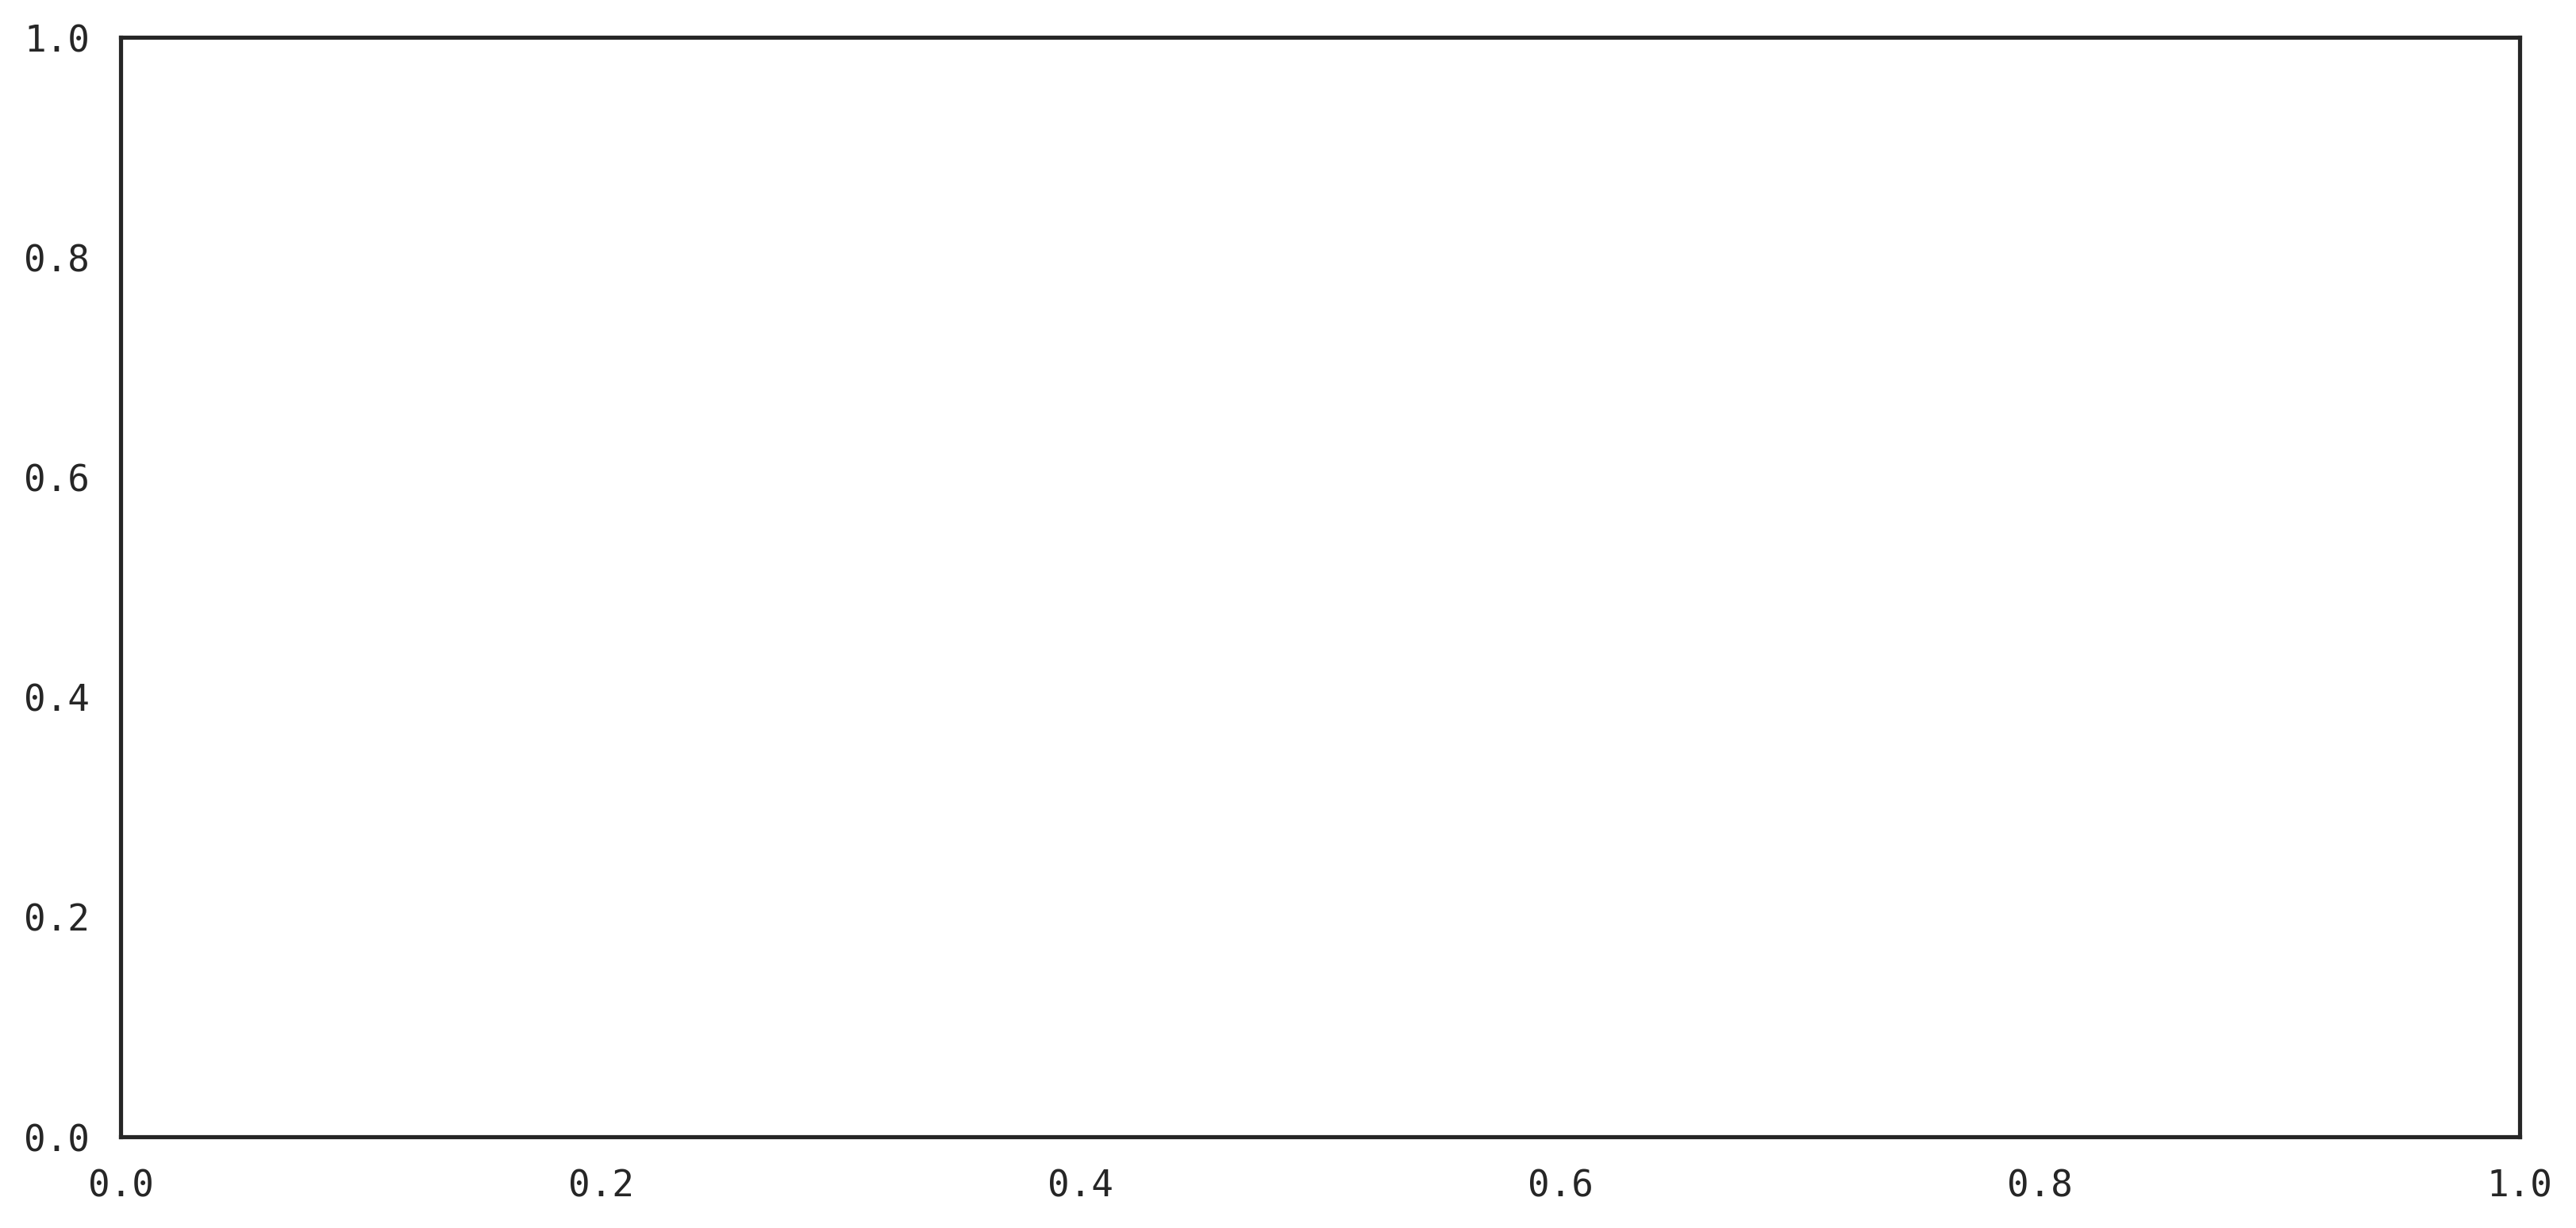

In [45]:
group_cols = ["reasoning_effort", "backend", "test_name"]
variance_col = "seed"
metric_col = "correct"
# query_filter = "reasoning_effort == 'medium'"
query_filter = "test_type == 'gpt_oss' and backend.str.startswith('burrito', na=False) and python_enabled == 0"


out = compute_group_variance(df, group_cols, variance_col, metric_col, query_filter)
# display_results(out)
plot_computed_results(out, group_cols, metric_col, plot_type="line", x_order=["low", "medium", "high"])